# Scaling experiment

Measure how the Stegosaurus worker pool behaves under load.

The binding constraint on worker pool size differs between GPU and CPU deployments, and the `WorkerManager` handles each case differently.

**GPU deployments**: VRAM is the bottleneck. Each worker loads an independent model copy into GPU memory, so `max_workers` is capped by `available_vram // model_vram_footprint`. CPU thread management is left to PyTorch defaults because the GPU kernel scheduler handles concurrency internally. Sections 2, 3, and 4 below were run on a GPU instance.

**CPU-only deployments**: RAM may be plentiful, but PyTorch inference uses all available cores for each forward pass. If workers are sized to memory alone, the pool may spawn too many processes and they thrash CPU cores, causing median latency to balloon (2+ minutes was observed in practice). The fix is two-fold:

1. `max_workers` is capped at `cpu_count` (via `os.sched_getaffinity`) in addition to the memory budget, so workers never outnumber cores.
2. A shared `threads_per_worker` integer (`multiprocessing.Value`) is updated after every scale event to `cpu_count // alive_workers`. Each worker calls `torch.set_num_threads()` before every job, giving every worker an equal slice of cores. A single worker gets all cores; as demand grows and more workers are spawned, each worker's slice shrinks but aggregate throughput rises. Sections 5 and 6 explore this trade-off on a CPU-only machine.

## Experiments

1. **Baseline** *(GPU)*: single worker latency vs concurrency level
2. **Worker sweep** *(GPU)*: fixed concurrency; vary `MAX_WORKERS`; observe latency + throughput
3. **Dynamic scaling trace** *(GPU)*: send a traffic burst and watch the pool auto-scale in real time
4. **Thread-per-worker scaling** *(CPU only)*: verify the thread-allocation strategy and measure per-worker latency vs thread count at low concurrency
5. **Optimal threads-per-worker sweep** *(CPU only)*: fixed large batch (64 jobs) at full concurrency; find the worker count where adding more workers stops improving throughput and starts hurting user latency

## 1. Set-up

### 1.1. Imports

In [1]:
import threading
import time

import matplotlib.pyplot as plt
import pandas as pd

from helpers import burst, count_workers, decode_one, encode_one, sample_workers, summarize

### 1.2. Configuration

Edit `APP_URL` to point at a running Stegosaurus instance.

In [2]:
APP_URL = 'http://localhost:8080'

# Payload used for every encode request
PROMPT = 'Write a short story about a lighthouse keeper.'
MESSAGE = 'hello'

# Section 2 - baseline
BASELINE_CONCURRENCY_LEVELS = [1, 2, 4, 8]
BASELINE_REQUESTS_PER_LEVEL = 10

# Section 3 - worker sweep
SWEEP_CONCURRENCY = 8             # fixed concurrent callers
SWEEP_REQUESTS = 20               # requests per max_workers setting
SWEEP_MAX_WORKERS = [1, 2, 4, 8]  # restart app between each

# Section 4 - dynamic scaling
BURST_CONCURRENCY = 8
BURST_REQUESTS = 30
SAMPLE_INTERVAL_S = 1.0           # how often to count worker processes

### 1.3. Data persistence

Experiment results are saved to `notebooks/data/` as JSON after each run. The restore cell below loads all available saved data. After a kernel restart, running the setup section (cells 1-3) is enough to regenerate any plot without re-running the experiments. Delete the relevant file in `data/` to force a fresh measurement.

In [ ]:
import json
from pathlib import Path

DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)


def save_data(filename, data):
    '''Save any JSON-serializable object to DATA_DIR/<filename>.'''

    path = DATA_DIR / filename

    with open(path, 'w') as f:
        json.dump(data, f, indent=2)

    n = len(data) if hasattr(data, '__len__') else ''
    print(f'Saved {n} to {path}')


def load_data(filename):
    '''Load a previously saved data file. Returns None if not found.'''

    path = DATA_DIR / filename

    if path.exists():
        with open(path) as f:
            return json.load(f)
    return None

In [ ]:
# Restore all saved experiment data.
# Run this after a kernel restart to regenerate plots without re-running the experiments.

_baseline = load_data('baseline_rows.json')
if _baseline:
    df_baseline = pd.DataFrame(_baseline)
    print(f'Loaded baseline:          {len(df_baseline)} rows')

_sweep = load_data('sweep_rows.json')
if _sweep:
    df_sweep = pd.DataFrame(_sweep).sort_values('max_workers')
    print(f'Loaded worker sweep:      {len(df_sweep)} rows')

_trace = load_data('scaling_trace.json')
if _trace:
    samples = [tuple(s) for s in _trace['samples']]
    burst_wall = _trace['burst_wall']
    print(f'Loaded scaling trace:     {len(samples)} samples')

_thread_sweep = load_data('thread_sweep_rows.json')
if _thread_sweep:
    df_thread_sweep = (
        pd.DataFrame(_thread_sweep)
        .sort_values('n_workers')
        .reset_index(drop=True)
    )
    print(f'Loaded thread sweep:      {len(df_thread_sweep)} rows')

_throughput_sweep = load_data('throughput_sweep_rows.json')
if _throughput_sweep:
    df_throughput_sweep = (
        pd.DataFrame(_throughput_sweep)
        .sort_values('n_workers')
        .reset_index(drop=True)
    )
    print(f'Loaded throughput sweep:  {len(df_throughput_sweep)} rows')

## 2. Baseline single worker *(GPU)*

Start the app with `MAX_WORKERS=1 MIN_WORKERS=1`, then run the cell below. Each concurrency level fires `BASELINE_REQUESTS_PER_LEVEL` requests with that many parallel threads.

In [ ]:
baseline_rows = load_data('baseline_rows.json')

if baseline_rows:
    print('Using saved baseline data. Delete data/baseline_rows.json to re-run.')
else:
    baseline_rows = []
    for concurrency in BASELINE_CONCURRENCY_LEVELS:
        times, wall = burst(APP_URL, PROMPT, MESSAGE, BASELINE_REQUESTS_PER_LEVEL, concurrency)
        stats = summarize(times, wall)
        baseline_rows.append({'concurrency': concurrency, **stats})
    save_data('baseline_rows.json', baseline_rows)

df_baseline = pd.DataFrame(baseline_rows)
df_baseline

,concurrency,n,min_s,median_s,p95_s,max_s,throughput_rps
0,1,10,6.98,7.04,7.14,7.14,0.14
1,2,10,6.78,7.11,14.00,14.00,0.23
2,4,10,7.19,7.36,14.44,14.44,0.44
3,8,10,7.56,14.42,15.05,15.05,0.45


### 2.1. Latency vs concurrency

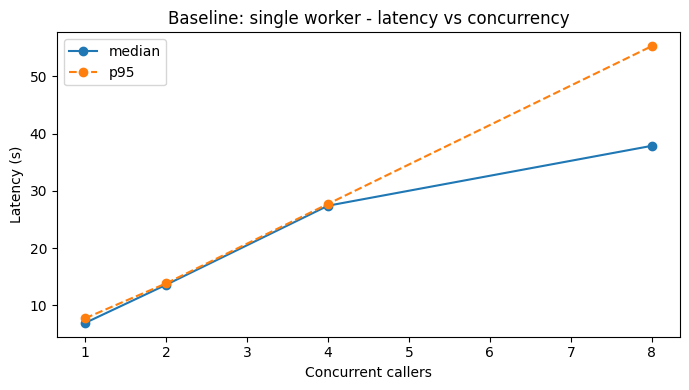

In [6]:
x = df_baseline['concurrency']
fig, ax = plt.subplots(figsize=(7, 4))
ax.set_title('Baseline: single worker - latency vs concurrency')
ax.plot(x, df_baseline['median_s'], marker='o', label='median')
ax.plot(x, df_baseline['p95_s'], marker='o', linestyle='--', label='p95')
ax.set_xlabel('Concurrent callers')
ax.set_ylabel('Latency (s)')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Worker sweep *(GPU)*

For each value in `SWEEP_MAX_WORKERS`:
1. Restart the app with `MAX_WORKERS=<n> MIN_WORKERS=<n>` (so the pool is pre-warmed).
2. Set `N_WORKERS_THIS_RUN = <n>` in the cell below.
3. Run the measurement cell.
4. Repeat for the next value.

The cell accumulates results into `df_sweep` across re-runs.

In [ ]:
# Set this to match the MAX_WORKERS value the app was started with, then run the cell.
# Re-run with a different value after restarting the app with a new MAX_WORKERS setting.
N_WORKERS_THIS_RUN = 8

sweep_rows = load_data('sweep_rows.json') or []

times, wall = burst(APP_URL, PROMPT, MESSAGE, SWEEP_REQUESTS, SWEEP_CONCURRENCY)
stats = summarize(times, wall)
sweep_rows.append({'max_workers': N_WORKERS_THIS_RUN, **stats})
save_data('sweep_rows.json', sweep_rows)

df_sweep = pd.DataFrame(sweep_rows).sort_values('max_workers')
df_sweep

,max_workers,n,min_s,median_s,p95_s,max_s,throughput_rps
0,1,20,6.90,53.00,54.28,54.28,0.15
1,2,20,8.07,28.11,29.30,29.30,0.28
2,4,20,8.45,14.84,16.33,16.33,0.51
3,8,20,7.33,8.65,9.84,9.84,0.76


### 3.1. Latency and throughput vs worker count

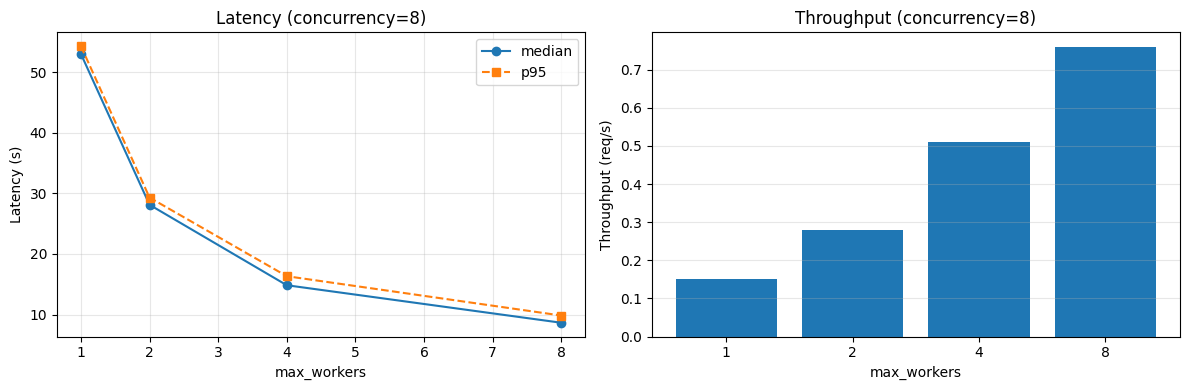

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

x = df_sweep['max_workers']

ax1.set_title(f'Latency (concurrency={SWEEP_CONCURRENCY})')
ax1.plot(x, df_sweep['median_s'], marker='o', label='median')
ax1.plot(x, df_sweep['p95_s'], marker='s', linestyle='--', label='p95')
ax1.set_xlabel('max_workers')
ax1.set_ylabel('Latency (s)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_title(f'Throughput (concurrency={SWEEP_CONCURRENCY})')
ax2.bar(x.astype(str), df_sweep['throughput_rps'])
ax2.set_xlabel('max_workers')
ax2.set_ylabel('Throughput (req/s)')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 4. Dynamic scaling trace *(GPU)*

Start the app with `MIN_WORKERS=1 MAX_WORKERS=4`. The cell below:
1. Polls `pgrep` in a background thread to count live worker processes.
2. Fires a burst of requests.
3. Keeps sampling until the pool quiesces back to `MIN_WORKERS`.

The result is a step-plot of worker count over time.

In [ ]:
QUIESCE_STABLE_S = 10    # stop sampling once count is stable for this long
QUIESCE_TIMEOUT_S = 180  # give up waiting after this many seconds

_saved = load_data('scaling_trace.json')

if _saved:
    samples = [tuple(s) for s in _saved['samples']]
    burst_wall = _saved['burst_wall']
    print(f'Loaded {len(samples)} samples from disk. Delete data/scaling_trace.json to re-run.')

else:
    # Allow a warm-up sample before the burst
    samples = []
    stop_event = threading.Event()
    sampler = threading.Thread(
        target=sample_workers,
        args=(stop_event, samples, SAMPLE_INTERVAL_S),
        daemon=True,
    )

    print('Sampling worker count before burst…')
    sampler.start()
    time.sleep(3)

    # Record the baseline pool size before the burst so the quiesce target
    # reflects whatever MIN_WORKERS the app was actually started with.
    baseline_count = samples[-1][1] if samples else 1
    print(f'Baseline worker count: {baseline_count}')

    print(f'Firing burst: {BURST_REQUESTS} requests at concurrency {BURST_CONCURRENCY}')
    burst_times, burst_wall = burst(APP_URL, PROMPT, MESSAGE, BURST_REQUESTS, BURST_CONCURRENCY)
    print(f'Burst complete in {burst_wall:.1f}s. Waiting for pool to quiesce…')

    # Keep sampling until the count has returned to baseline and been stable
    # for QUIESCE_STABLE_S, or until QUIESCE_TIMEOUT_S elapses.
    prev_count = None
    stable_since = time.perf_counter()
    quiesce_deadline = time.perf_counter() + QUIESCE_TIMEOUT_S

    while True:
        time.sleep(SAMPLE_INTERVAL_S)
        current = count_workers()

        if current != prev_count:
            stable_since = time.perf_counter()
            prev_count = current

        if current <= baseline_count and (time.perf_counter() - stable_since) >= QUIESCE_STABLE_S:
            break

        if time.perf_counter() >= quiesce_deadline:
            print(f'Warning: quiesce timeout reached; last worker count was {current} (baseline {baseline_count})')
            break

    stop_event.set()
    sampler.join()
    print(f'Done. Collected {len(samples)} samples.')

    save_data('scaling_trace.json', {
        'samples': [list(s) for s in samples],
        'burst_wall': burst_wall,
    })

Sampling worker count before burst…
Baseline worker count: 1
Firing burst: 30 requests at concurrency 8
Burst complete in 68.9s. Waiting for pool to quiesce…
Done. Collected 112 samples.


### 4.1. Worker count over time

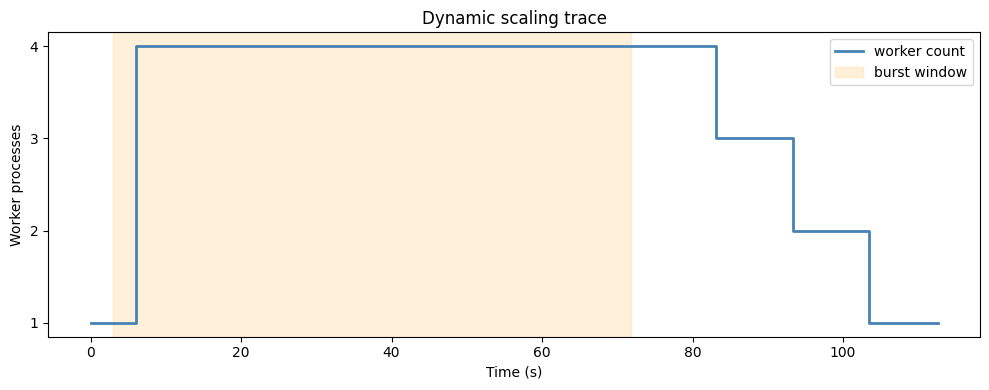

Burst summary: {'n': 30, 'min_s': 7.96, 'median_s': 14.76, 'p95_s': 28.99, 'max_s': 29.9, 'throughput_rps': 0.44}


In [ ]:
ts, counts = zip(*samples)

# Approximate burst window: t=3s to t=3+burst_wall
burst_start_t = 3.0
burst_end_t = burst_start_t + burst_wall

fig, ax = plt.subplots(figsize=(10, 4))
ax.set_title('Dynamic scaling trace')
ax.step(ts, counts, where='post', color='steelblue', linewidth=2, label='worker count')
ax.axvspan(burst_start_t, burst_end_t, alpha=0.15, color='orange', label='burst window')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Worker processes')
ax.yaxis.get_major_locator().set_params(integer=True)
ax.legend()
plt.tight_layout()
plt.show()

## 5. Thread-per-worker scaling *(CPU only)*

The `WorkerManager` keeps a shared `threads_per_worker` integer equal to `cpu_count // alive_workers`. Workers read it before every job and call `torch.set_num_threads()`, so the thread budget redistributes automatically without restarting any process.

Two analyses:
- **5.1 Simulation** - show the allocation math for every possible pool size on this machine.
- **5.2 Empirical** - measure single-request latency while the pool is pinned to N workers, confirming that per-worker speed trades off against aggregate throughput as threads shrink.

In [ ]:
# Section 5 config
# Number of workers to sweep in the empirical test (5.2).
# Restart the app with MAX_WORKERS=N MIN_WORKERS=N for each value.
THREAD_SWEEP_WORKERS = [4, 8, 16, 32]   # adjust to <= your cpu_count
THREAD_SWEEP_REQUESTS = 10              # single-request runs to average (concurrency=1)

### 5.1 Simulation - thread allocation per pool size

The table and chart below are computed locally from `os.sched_getaffinity(0)`; no running app required. They show exactly what `threads_per_worker` will be for each alive-worker count, and that `threads × workers` never exceeds `cpu_count` (cores are shared, never over-subscribed).

In [4]:
import os

try:
    cpu_count = len(os.sched_getaffinity(0))
except AttributeError:
    cpu_count = os.cpu_count() or 1

thread_rows = []
for n_workers in range(1, cpu_count + 1):
    tpw = max(1, cpu_count // n_workers)
    thread_rows.append({
        'workers': n_workers,
        'threads_per_worker': tpw,
        'total_threads_in_use': tpw * n_workers,
        'idle_cores': max(0, cpu_count - tpw * n_workers),
    })

df_threads = pd.DataFrame(thread_rows)
print(f'cpu_count = {cpu_count}')
df_threads

cpu_count = 24


,workers,threads_per_worker,total_threads_in_use,idle_cores
0,1,24,24,0
1,2,12,24,0
2,3,8,24,0
3,4,6,24,0
4,5,4,20,4
5,6,4,24,0
6,7,3,21,3
7,8,3,24,0
8,9,2,18,6
9,10,2,20,4


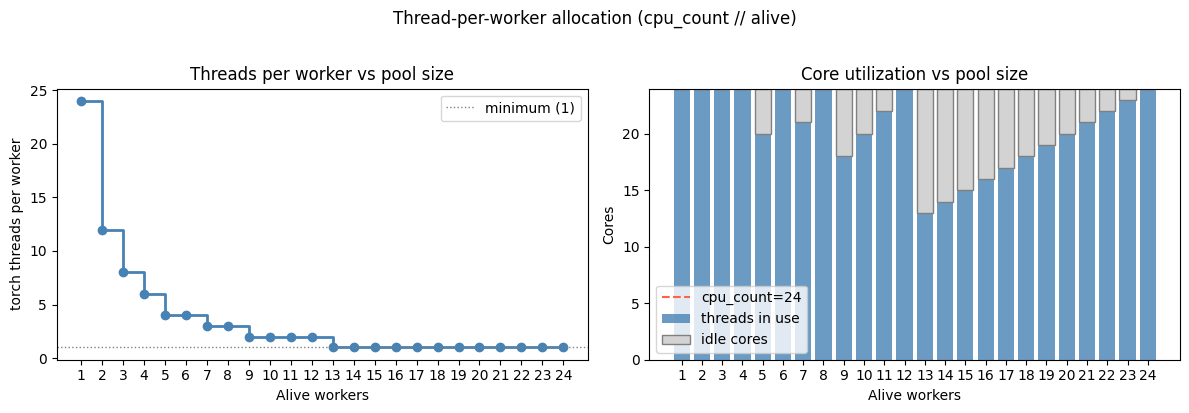

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

plt.suptitle('Thread-per-worker allocation (cpu_count // alive)', y=1.02)

x = df_threads['workers']

ax1.set_title('Threads per worker vs pool size')
ax1.step(
    x, df_threads['threads_per_worker'],
    where='post', color='steelblue',
    linewidth=2, marker='o'
)
ax1.set_xlabel('Alive workers')
ax1.set_ylabel('torch threads per worker')
ax1.set_xticks(x)

ax1.axhline(
    1, color='grey',
    linestyle=':', linewidth=1,
    label='minimum (1)'
)
ax1.legend()

ax2.set_title('Core utilization vs pool size')
ax2.bar(
    x.astype(str), df_threads['total_threads_in_use'],
    label='threads in use', color='steelblue', alpha=0.8
)
ax2.bar(
    x.astype(str), df_threads['idle_cores'],
    bottom=df_threads['total_threads_in_use'],
   label='idle cores', color='lightgrey', edgecolor='grey'
)
ax2.axhline(
    cpu_count, color='tomato', 
    linestyle='--', linewidth=1.5, 
    label=f'cpu_count={cpu_count}'
)
ax2.set_xlabel('Alive workers')
ax2.set_ylabel('Cores')
ax2.legend()

plt.tight_layout()
plt.show()

### 5.2 Empirical – latency vs threads per worker

For each `N` in `THREAD_SWEEP_WORKERS`:
1. Restart the app: `MAX_WORKERS=N MIN_WORKERS=N python demo/app.py` (pre-warming to N avoids cold-start noise).
2. Set `N_WORKERS_THIS_RUN = N` in the cell below and run it.
3. Repeat for the next value.

With concurrency=1 only one worker is busy at a time, so we isolate the effect of `torch.set_num_threads(cpu_count // N)` on per-request latency.

In [ ]:
# Set this to match the MAX_WORKERS=MIN_WORKERS value the app was started with.
N_WORKERS_THIS_RUN = 32

thread_sweep_rows = load_data('thread_sweep_rows.json') or []

# concurrency=1: single sequential requests so each measures one worker in isolation.
times, wall = burst(APP_URL, PROMPT, MESSAGE, THREAD_SWEEP_REQUESTS, n_workers=1)
stats = summarize(times, wall)

# Annotate with the expected thread count for this run.
expected_threads = max(1, cpu_count // N_WORKERS_THIS_RUN)

thread_sweep_rows.append({
    'n_workers': N_WORKERS_THIS_RUN,
    'threads_per_worker': expected_threads,
    **stats,
})
save_data('thread_sweep_rows.json', thread_sweep_rows)

df_thread_sweep = (
    pd.DataFrame(thread_sweep_rows)
    .sort_values('n_workers')
    .reset_index(drop=True)
)

df_thread_sweep

,n_workers,threads_per_worker,n,min_s,median_s,p95_s,max_s,throughput_rps
0,4,6,10,8.39,8.64,9.24,9.24,0.11
1,8,3,10,9.69,9.94,10.39,10.39,0.10
2,16,1,10,18.06,18.43,19.10,19.10,0.05
3,32,1,10,18.20,18.57,19.00,19.00,0.05


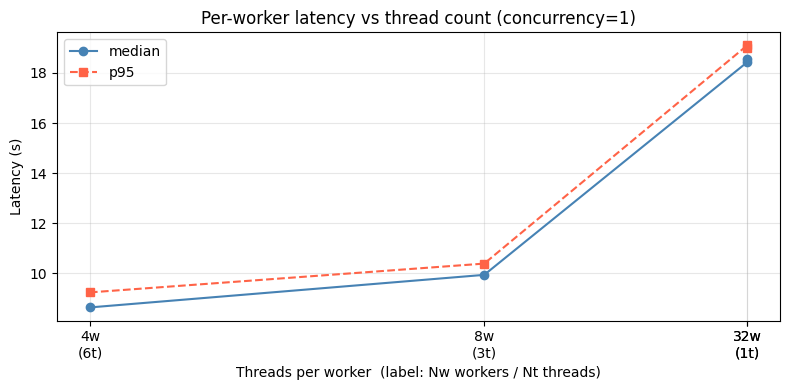


Theoretical max throughput at full concurrency (n_workers / median_latency):
 n_workers  threads_per_worker  median_s  theoretical_rps
         4                   6      8.64             0.46
         8                   3      9.94             0.80
        16                   1     18.43             0.87
        32                   1     18.57             1.72


In [ ]:
if len(df_thread_sweep) < 2:
    print('Run the cell above for at least 2 worker counts before plotting.')

else:
    x = df_thread_sweep['threads_per_worker']
    labels = [
        f'{row.n_workers}w\n({row.threads_per_worker}t)'
        for row in df_thread_sweep.itertuples()
    ]

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.set_title('Per-worker latency vs thread count (concurrency=1)')
    ax.plot(x, df_thread_sweep['median_s'], marker='o', label='median', color='steelblue')
    ax.plot(x, df_thread_sweep['p95_s'], marker='s', linestyle='--', label='p95', color='tomato')
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_xlabel('Threads per worker  (label: Nw workers / Nt threads)')
    ax.set_ylabel('Latency (s)')
    ax.invert_xaxis()   # more workers → fewer threads → moving left feels natural
    ax.legend()
    plt.tight_layout()
    plt.show()

    # Also show the throughput headroom: at SWEEP_CONCURRENCY concurrent callers,
    # N workers with median latency L can serve N/L requests/s theoretical max.
    df_thread_sweep['theoretical_rps'] = (
        df_thread_sweep['n_workers'] / df_thread_sweep['median_s']
    ).round(2)

    print('\nTheoretical max throughput at full concurrency (n_workers / median_latency):')
    print(
        df_thread_sweep[
            ['n_workers', 'threads_per_worker', 'median_s', 'theoretical_rps']
        ].to_string(index=False)
    )

## 6. Optimal threads-per-worker sweep *(CPU only)*

Sections 5.1 and 5.2 showed that more workers means fewer threads each. This experiment finds the crossover point where the per-job slowdown from fewer threads outweighs the benefit of extra parallelism.

**Setup**: 64 jobs are submitted simultaneously with concurrency equal to the worker count, so every worker is busy for the whole run. We measure:
- **User latency**: how long each individual request waits (median and p95). This is what a real user experiences.
- **Total wall time**: how long the whole batch of 64 jobs takes. This is throughput from the server's perspective.

For each `N` in `THROUGHPUT_SWEEP_WORKERS`, restart the app with `MAX_WORKERS=N MIN_WORKERS=N`, then run the measurement cell.

In [12]:
TOTAL_JOBS = 64   # fixed batch size - large enough to keep all workers busy

# Worker counts to sweep. Concurrency is set equal to worker count so every
# worker is occupied for the full run. Should be <= cpu_count.
THROUGHPUT_SWEEP_WORKERS = [1, 2, 4, 8, 16, 32]

### 6.1 Measurement

Set `N_WORKERS_THIS_RUN` to match the `MAX_WORKERS=MIN_WORKERS` value the app was started with, then run the cell. Re-run after each restart.

In [ ]:
# Set this to match MAX_WORKERS=MIN_WORKERS the app was started with, then run.
N_WORKERS_THIS_RUN = 8

throughput_sweep_rows = load_data('throughput_sweep_rows.json') or []

# Concurrency = worker count: every worker is kept busy for the whole batch.
times, wall = burst(APP_URL, PROMPT, MESSAGE, TOTAL_JOBS, n_workers=N_WORKERS_THIS_RUN)
stats = summarize(times, wall)

throughput_sweep_rows.append({
    'n_workers': N_WORKERS_THIS_RUN,
    'threads_per_worker': max(1, cpu_count // N_WORKERS_THIS_RUN),
    'total_wall_s': round(wall, 2),
    **stats,
})
save_data('throughput_sweep_rows.json', throughput_sweep_rows)

df_throughput_sweep = (
    pd.DataFrame(throughput_sweep_rows)
    .sort_values('n_workers')
    .reset_index(drop=True)
)
df_throughput_sweep[['n_workers', 'threads_per_worker', 'total_wall_s', 'median_s', 'p95_s', 'throughput_rps']]

,n_workers,threads_per_worker,total_wall_s,median_s,p95_s,throughput_rps
0,1,24,2155.37,33.49,37.10,0.03
1,2,12,517.63,15.99,17.33,0.12
2,4,6,301.98,18.69,19.44,0.21


### 6.2 Results

In [ ]:
if len(df_throughput_sweep) < 2:
    print('Run the measurement cell for at least 2 worker counts before plotting.')
else:
    x = df_throughput_sweep['n_workers']
    x_labels = [f"{row.n_workers}w\n({row.threads_per_worker}t)"
                for row in df_throughput_sweep.itertuples()]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f'Throughput sweep – {TOTAL_JOBS} jobs, concurrency = worker count', y=1.02)

    # --- User latency (what the user actually waits for) ---
    ax = axes[0]
    ax.set_title('User latency')
    ax.plot(x, df_throughput_sweep['median_s'], marker='o', label='median', color='steelblue')
    ax.plot(x, df_throughput_sweep['p95_s'], marker='s', linestyle='--', label='p95', color='tomato')
    ax.set_xlabel('Workers (threads each)')
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels)
    ax.set_ylabel('Latency (s)')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # --- Total wall time (server throughput) ---
    ax = axes[1]
    ax.set_title(f'Total wall time ({TOTAL_JOBS} jobs)')
    ax.plot(x, df_throughput_sweep['total_wall_s'], marker='o', color='seagreen')
    ax.set_xlabel('Workers (threads each)')
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels)
    ax.set_ylabel('Wall time (s)')
    ax.grid(True, alpha=0.3)

    # --- Throughput (req/s) ---
    ax = axes[2]
    ax.set_title('Throughput')
    ax.bar(x_labels, df_throughput_sweep['throughput_rps'], color='steelblue', alpha=0.8)
    ax.set_xlabel('Workers (threads each)')
    ax.set_ylabel('Req / s')
    ax.grid(True, alpha=0.3, axis='y')

    # Mark the best throughput
    best_idx = df_throughput_sweep['throughput_rps'].idxmax()
    best_n = df_throughput_sweep.loc[best_idx, 'n_workers']
    best_tpw = df_throughput_sweep.loc[best_idx, 'threads_per_worker']
    axes[2].annotate(
        f'best\n{best_n}w/{best_tpw}t',
        xy=(best_idx, df_throughput_sweep.loc[best_idx, 'throughput_rps']),
        xytext=(0, 10), textcoords='offset points',
        ha='center', fontsize=9, color='tomato',
        arrowprops=dict(arrowstyle='->', color='tomato'),
    )

    plt.tight_layout()
    plt.show()

    print(f'\nBest throughput: {best_n} workers ({best_tpw} threads each) '
          f'→ {df_throughput_sweep.loc[best_idx, "throughput_rps"]:.2f} req/s, '
          f'median latency {df_throughput_sweep.loc[best_idx, "median_s"]:.1f}s')